# Hotel Booking System:

### Business Understanding

#### Business Problem: 
    Hotels experience booking cancellations, fluctuating demand, and varying customer preferences. These factors affect occupancy rates, revenue and opertional planning.


#### Industry/Domain of dataset:
    Hospitality and Hotel management Industry.

#### Objective:
    To analyze hotel booking patterns, customer behavior and cancellation trends to generate business insights and recommendations.

#### Importance of Analysis:
    Understanding booking behavior help hotels improve occupancy, reduce cancellations, optimize pricing, and increase profitability.

#### Important KPIs:
   1. Total Bookings
   2. Cancellation rate(%)
   3. Successful Bookings
   4. Average Daily Rate(ADR)
   5. Average Lead Time
   6. Average Stay Duration
   7. Total Guests
   8. Occupancy Rate(%)
   9. Hotel-wise Bookings
  10. Revenue Indicator

#### Analysis Approach:
    This project uses EDA techniques — data cleaning, visualization, pivot tables, GroupBy analysis, and correlation analysis — to explore booking patterns and customer behavior.
#### How Data Helps Solve the Problem:
   1. By analyzing historical booking data, we can identify which customer segments cancel most, which months generate peak revenue, and which pricing strategies are most effective.
   2. These insights allow hotel management to make data-driven decisions to reduce cancellations, optimize pricing, and improve overall occupancy rates. where to add this



#### 2. Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [2]:
#Load Dataset

In [3]:
df=pd.read_csv("hotel_bookings_updated_2024.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2024-07-27 22:16:40.916332324,Chandigarh
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2024-04-28 21:56:21.507509066,Mumbai
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2024-09-10 03:46:25.734029096,Delhi
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2024-08-14 18:07:10.049669568,Kolkata
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2024-09-14 14:27:32.473846000,Lucknow


In [4]:
#Data Cleaning

In [5]:
# Shows number of rows and columns
df.shape

(119390, 33)

In [6]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'city'],
      dtype='object')

In [7]:
# Shows datatype of every column
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.0,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2024.0,26.375835,15.723394,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.0,15.021596,8.805079,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2024.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2024.0,13.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2024.0,26.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2024.0,39.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2024.0,52.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [10]:
# Count missing values
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [11]:
# Check duplicate rows
df.duplicated().sum()

0

In [12]:
# Fill missing values

df['children'].fillna(df['children'].median(),
                      inplace=True)

df['country'].fillna(df['country'].mode()[0],
                     inplace=True)

df['agent'].fillna(0,
                   inplace=True)

df['company'].fillna(0,
                     inplace=True)

C:\Users\grow\AppData\Local\Temp\ipykernel_8720\205496129.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(df['children'].median(),
C:\Users\grow\AppData\Local\Temp\ipykernel_8720\205496129.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [13]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [14]:
# Remove duplicate records

df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

0

In [16]:
(df.isnull().sum()/len(df))*100

hotel                             0.0
is_canceled                       0.0
lead_time                         0.0
arrival_date_year                 0.0
arrival_date_month                0.0
arrival_date_week_number          0.0
arrival_date_day_of_month         0.0
stays_in_weekend_nights           0.0
stays_in_week_nights              0.0
adults                            0.0
children                          0.0
babies                            0.0
meal                              0.0
country                           0.0
market_segment                    0.0
distribution_channel              0.0
is_repeated_guest                 0.0
previous_cancellations            0.0
previous_bookings_not_canceled    0.0
reserved_room_type                0.0
assigned_room_type                0.0
booking_changes                   0.0
deposit_type                      0.0
agent                             0.0
company                           0.0
days_in_waiting_list              0.0
customer_typ

In [17]:
(df['is_canceled'].sum()/len(df))*100

37.041628277075134

##### Business Meaning

    Percentage of bookings that were cancelled.

##### Importance

    Higher cancellation means revenue loss.

In [18]:
#Average Daily Rate(ADR)
df['adr'].mean()

101.83112153446686

##### Business Meaning:

    Average room price charged per booking.

##### Importance:

    Directly impacts revenue.

In [19]:
df["total_guests"]=df["adults"]+df["children"]+df["babies"]

##### Purpose:

    Calculates total guests per booking.

##### Business Use:

    Measures hotel occupancy demand.

In [20]:
df["total_stay"]=df["stays_in_week_nights"]+df["stays_in_weekend_nights"]

##### Purpose:

    Calculates total stay duration.

##### Business Use:

    Helps understand customer stay behavior.

In [21]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'city', 'total_guests',
       'total_stay'],
      dtype='object')

In [22]:
# Remove unnecessary columns

df.drop(['reservation_status_date'],
        axis=1,
        inplace=True)

In [23]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'city', 'total_guests', 'total_stay'],
      dtype='object')

In [24]:
# Check invalid guest records

df[
    (df['adults']+
     df['children']+
     df['babies'])==0
]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,city,total_guests,total_stay
2224,Resort Hotel - Delhi,0,1,2024,March,10,10,0,3,0,...,174.0,0,Transient-Party,0.00,0,0,Check-Out,Delhi,0.0,3
2409,Resort Hotel - Lucknow,0,0,2024,January,4,25,0,0,0,...,174.0,0,Transient,0.00,0,0,Check-Out,Lucknow,0.0,0
3181,Resort Hotel - Ahmedabad,0,36,2024,February,7,18,1,2,0,...,0.0,0,Transient-Party,0.00,0,0,Check-Out,Ahmedabad,0.0,3
3684,Resort Hotel - Pune,0,165,2024,October,41,9,1,4,0,...,0.0,122,Transient-Party,0.00,0,0,Check-Out,Pune,0.0,5
3708,Resort Hotel - Jaipur,0,165,2024,October,40,5,2,4,0,...,0.0,122,Transient-Party,0.00,0,0,Check-Out,Jaipur,0.0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,City Hotel - Jaipur,0,107,2024,October,44,30,0,3,0,...,0.0,0,Transient,100.80,0,0,Check-Out,Jaipur,0.0,3
115091,City Hotel - Chandigarh,0,1,2024,November,48,30,0,1,0,...,0.0,0,Transient,0.00,1,1,Check-Out,Chandigarh,0.0,1
116251,City Hotel - Kochi,0,44,2024,January,2,11,1,1,0,...,0.0,0,Transient,73.80,0,0,Check-Out,Kochi,0.0,2
116534,City Hotel - Ahmedabad,0,2,2024,March,10,6,2,5,0,...,0.0,0,Transient-Party,22.86,0,1,Check-Out,Ahmedabad,0.0,7


In [25]:
# Total Nights

df['total_nights'] = (
    df['stays_in_weekend_nights']
    + 
    df['stays_in_week_nights']
)

In [26]:
# Total Guests

df['total_guests'] = (
    df['adults']
    +
    df['children']
    +
    df['babies']
)

In [27]:
# Revenue

df['revenue'] = (
    df['adr']
    *
    df['total_nights']
)

In [28]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'city', 'total_guests', 'total_stay',
       'total_nights', 'revenue'],
      dtype='object')

#### 3. Exploratory Data Analysis (EDA)
A. Univariate Analysis

C:\Users\grow\AppData\Local\Temp\ipykernel_8720\3347428535.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


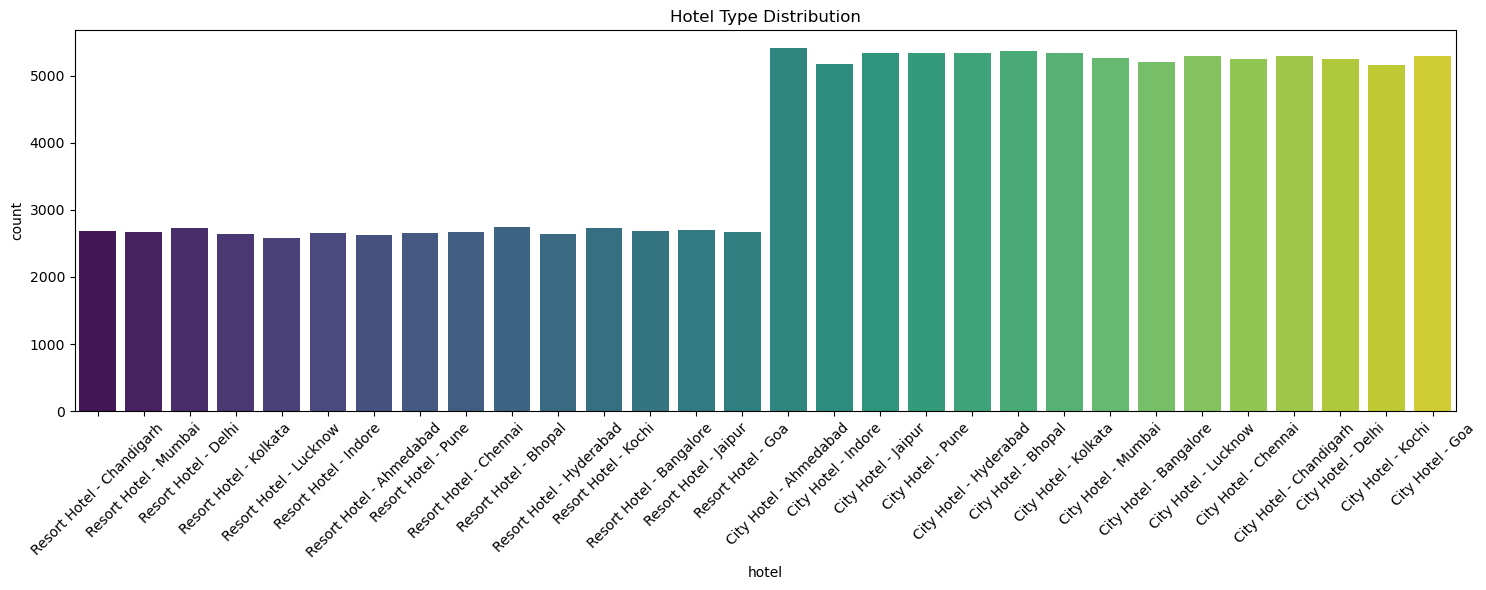

In [65]:
plt.figure(figsize=(15,6))

sns.countplot(
    x="hotel",
    data=df,
    palette="viridis"   
)

plt.title("Hotel Type Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Observation:

    City Hotels have more bookings than Resort Hotels.

##### Insight:

    Most travelers prefer city locations for business and tourism.

##### Business Impact:

    Understanding which hotel type receives more bookings helps management allocate resources, staffing, and marketing budgets effectively..

##### Recommendation:

    Invest more in city hotel marketing and premium services.

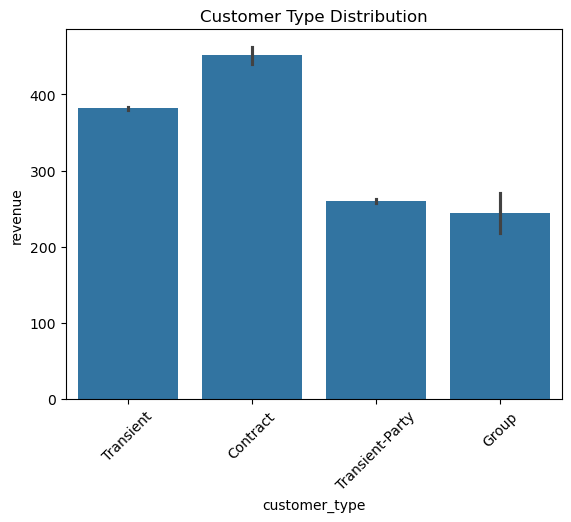

In [30]:
sns.barplot(x='customer_type',y="revenue",
              data=df)
plt.title("Customer Type Distribution")
plt.xticks(rotation=45)
plt.show()

##### Observation:

    Transient customers generate the highest revenue.

##### Insight:

    Individual travelers form the majority of customers.

##### Business Impact:

    Understanding customer behavior enables hotels to create personalized services and improve customer retention.

##### Recommendation:

    Create loyalty programs and personalized offers.

B. Bivariate Analysis


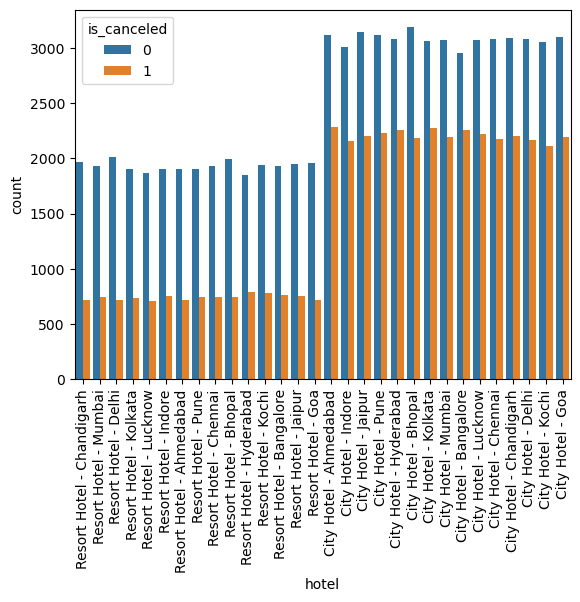

In [32]:
#Hotel vs Cancellation
sns.countplot(x='hotel',
              hue='is_canceled',
              data=df)
plt.xticks(rotation=90)
plt.show()

##### Observation:

    Cancellation differs by hotel type.

##### Insight:

    Customer behavior varies.

##### Business Insight:
    One hotel type may be more vulnerable to cancellations.

##### Conclusion:
    cancellation management strategies should target the hotel with higher cancellation rates.

C:\Users\grow\AppData\Local\Temp\ipykernel_8720\744406741.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


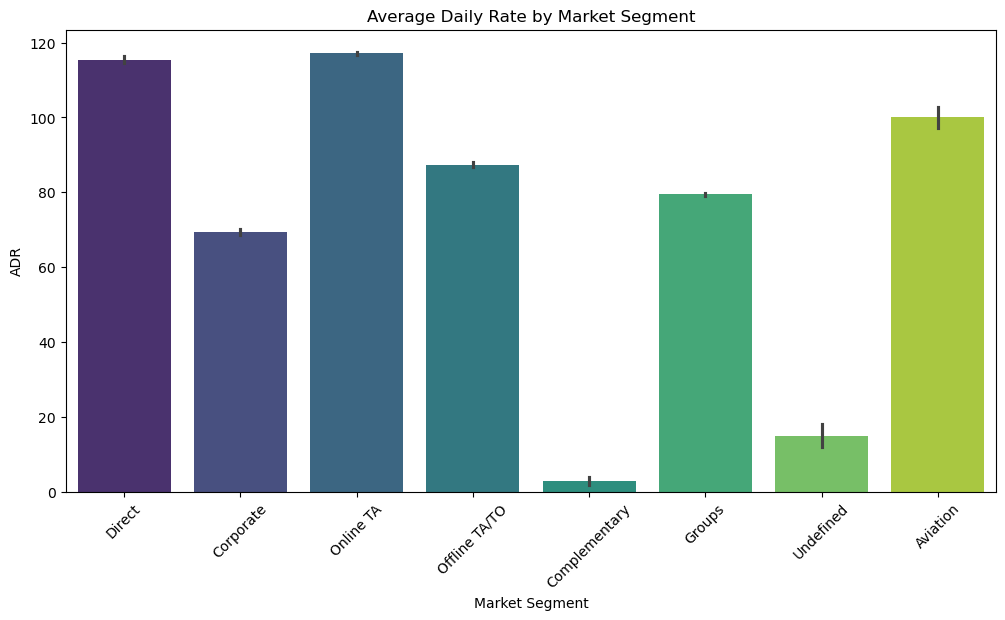

In [33]:
#Market Segment vs ADR
plt.figure(figsize=(12,6))

sns.barplot(
    x='market_segment',
    y='adr',
    data=df,
    palette='viridis'
)

plt.title('Average Daily Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('ADR')
plt.xticks(rotation=45)

plt.show()

##### Observation:

    ADR varies across different market segments.

##### Insight:

    Some customer segments are willing to pay higher room prices than others.

##### Business Impact:

    Market segments with higher ADR generate more revenue for the hotel.

##### Conclusion:

    Market segment significantly influences hotel pricing and revenue. Identifying high-paying customer groups helps improve business performance.

C. Multivariate Analysis

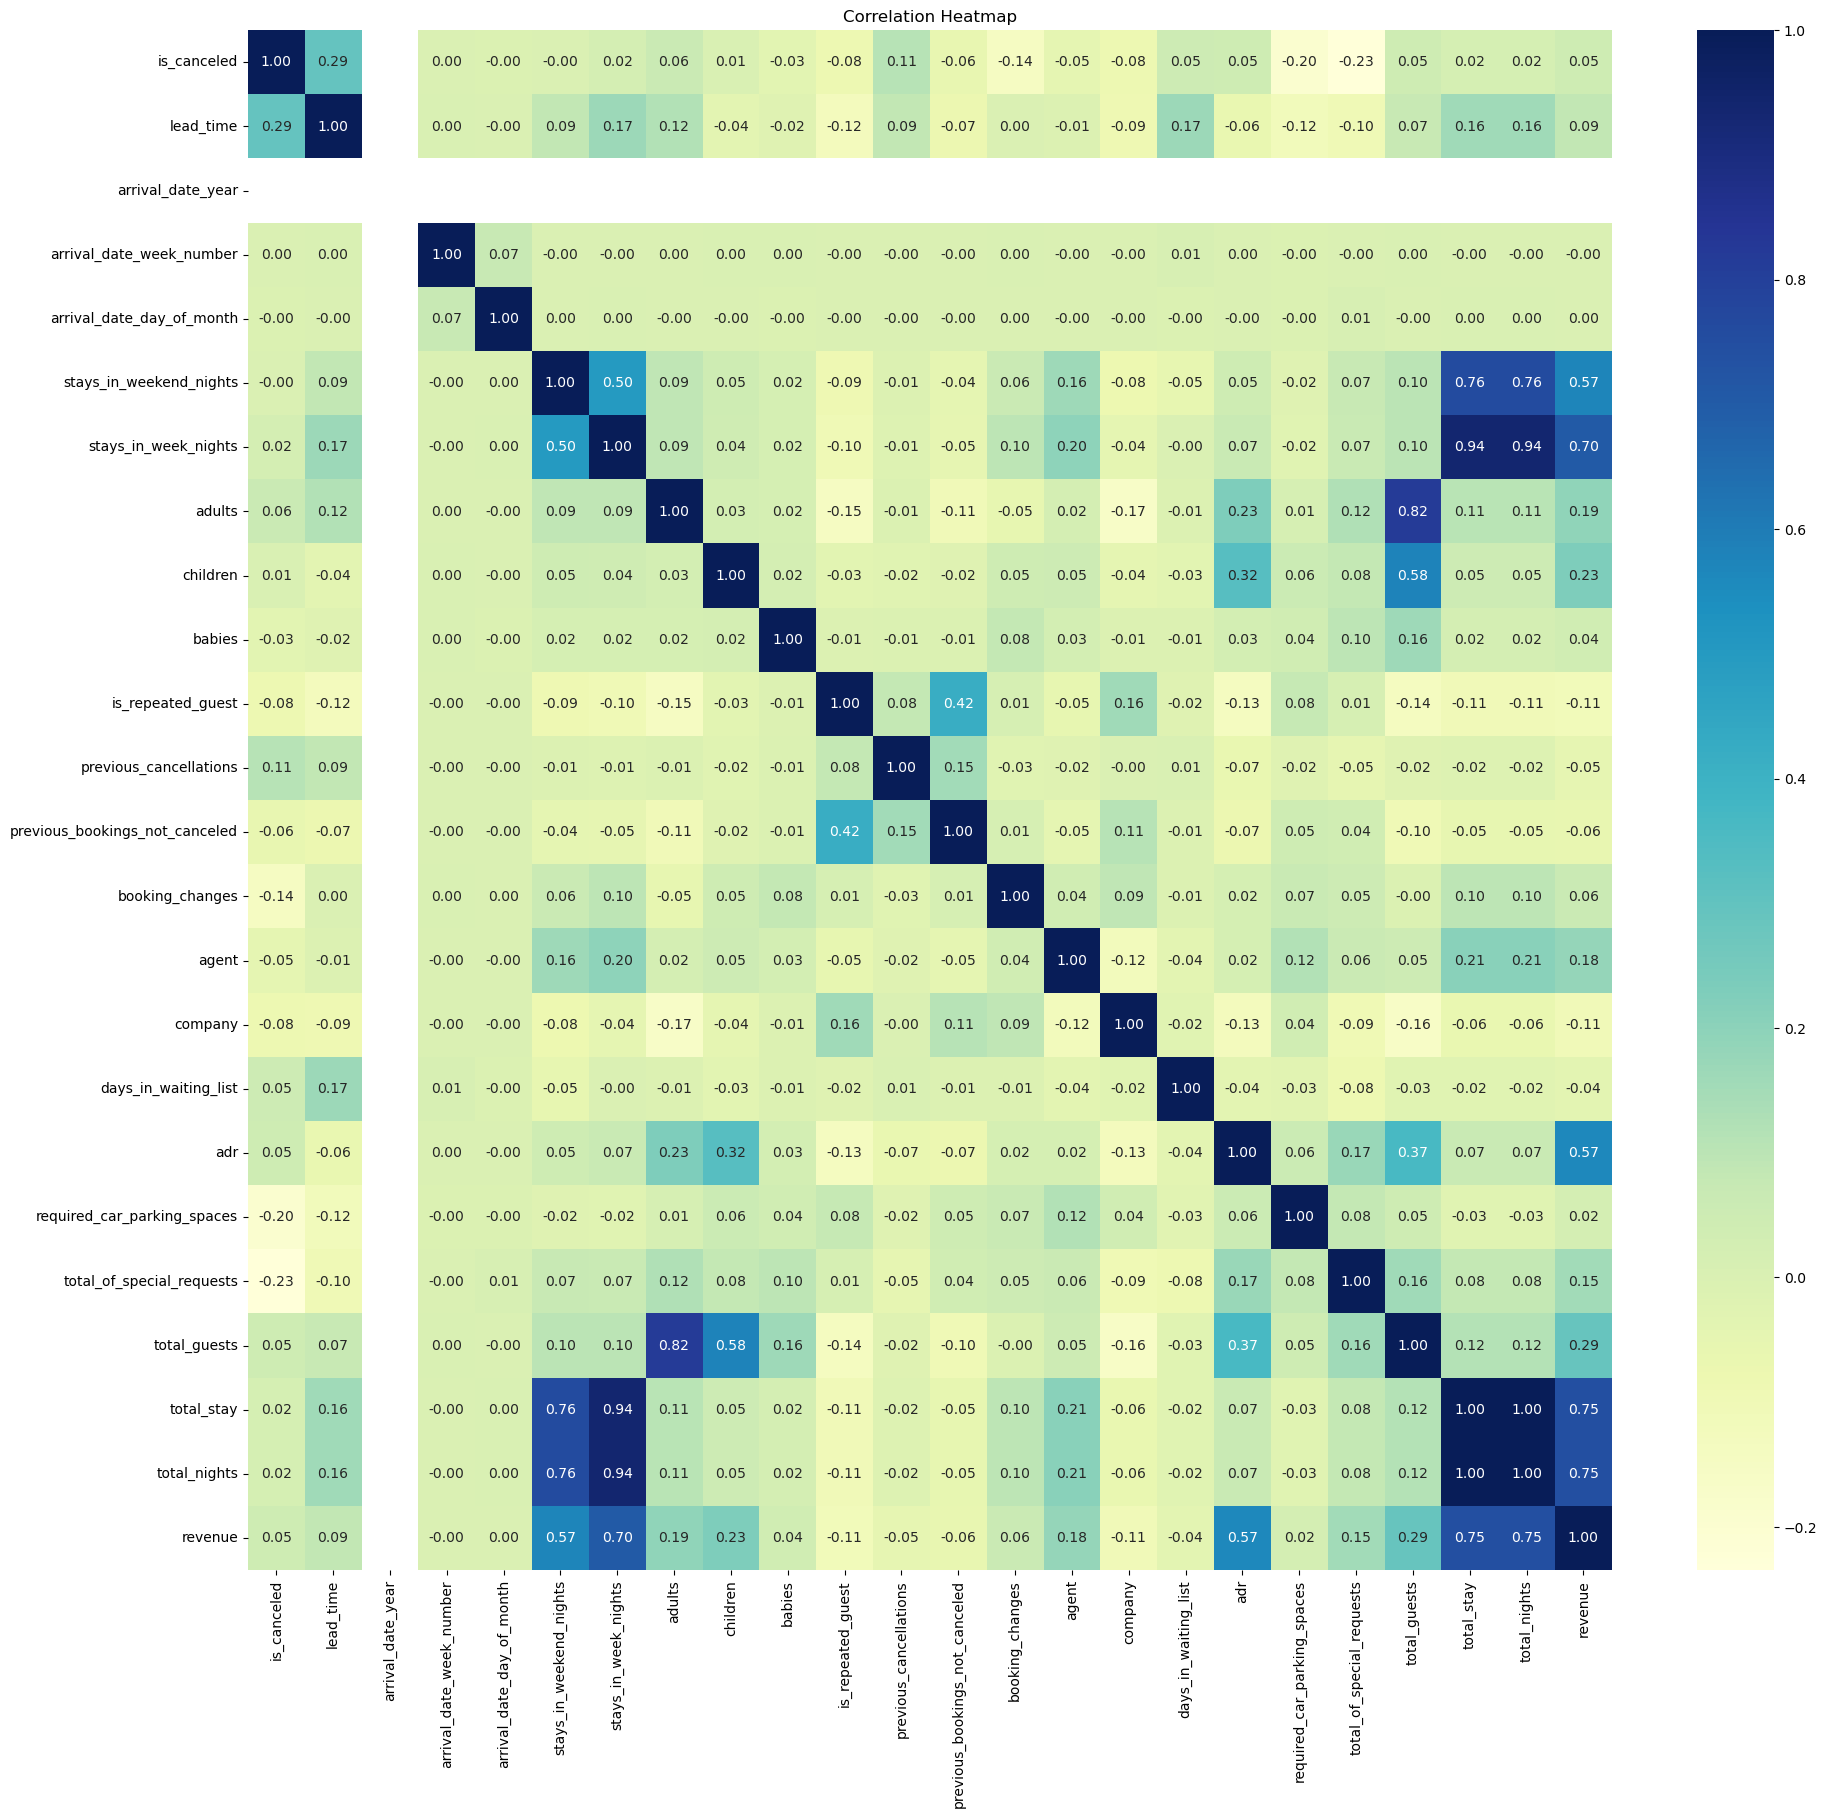

In [34]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(22,20))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='YlGnBu',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

##### Observation:

    Some variables have strong relationships with each other.

##### Insight:

    When one variable increases, the related variable may also increase or decrease.

##### Business Impact:

    Helps identify factors affecting revenue, bookings, and customer behavior.

##### Conclusion:

    The heatmap helps find important variables that influence hotel performance and supports better business decisions.

In [35]:
#Deposit Type + Lead Time + Cancellation
df.groupby(
    ['deposit_type','is_canceled']
)['lead_time'].mean()

deposit_type  is_canceled
No Deposit    0               79.832201
              1              111.281639
Non Refund    0              106.215054
              1              213.593487
Refundable    0              151.325397
              1              154.805556
Name: lead_time, dtype: float64

##### Observation:

    The average lead time differs based on deposit type and cancellation status.

##### Insight:

    Customers who book much earlier are more likely to cancel their bookings.

##### Business Impact:

    Higher cancellations can lead to revenue loss and difficulty in occupancy planning.

##### Conclusion:

    Lead time and deposit type influence cancellation behavior. Hotels can reduce cancellations by encouraging deposit-based bookings.

In [36]:
#market Segment + Hotel + Revenue
df.groupby(
    ['market_segment','hotel']
)['revenue'].sum()

market_segment  hotel                  
Aviation        City Hotel - Ahmedabad       5776.00
                City Hotel - Bangalore      10208.70
                City Hotel - Bhopal          8025.00
                City Hotel - Chandigarh      5145.00
                City Hotel - Chennai         8443.00
                                             ...    
Online TA       Resort Hotel - Lucknow     584237.93
                Resort Hotel - Mumbai      568004.35
                Resort Hotel - Pune        590145.07
Undefined       City Hotel - Bangalore         12.00
                City Hotel - Hyderabad         36.00
Name: revenue, Length: 197, dtype: float64

##### Observation:

    Revenue varies across different market segments and hotel types.

##### Insight:

    Some market segments generate more revenue than others, and revenue contribution differs between City Hotels and Resort Hotels.

##### Business Impact:

    Identifying high-revenue market segments helps hotels focus on the most profitable customer groups.

##### Conclusion:

    Market segment and hotel type significantly influence revenue. Hotels should target the segments that generate the highest revenue to improve profitability.

In [37]:
#Descriptive Statistics
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_stay,total_nights,revenue
count,119390.000000,119390.000000,119390.0,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2024.0,26.375835,15.723394,0.927599,2.500302,1.856403,0.103886,0.007949,...,74.828319,10.775157,2.321149,101.831122,0.062518,0.571363,1.968239,3.427900,3.427900,357.848208
std,0.482918,106.863097,0.0,15.021596,8.805079,0.998613,1.908286,0.579261,0.398555,0.097436,...,107.141953,53.943884,17.594721,50.535790,0.245291,0.792798,0.722394,2.557439,2.557439,335.910109
min,0.000000,0.000000,2024.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,0.000000,0.000000,0.000000,-63.800000
25%,0.000000,18.000000,2024.0,13.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,7.000000,0.000000,0.000000,69.290000,0.000000,0.000000,2.000000,2.000000,2.000000,146.000000
50%,0.000000,69.000000,2024.0,26.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,9.000000,0.000000,0.000000,94.575000,0.000000,0.000000,2.000000,3.000000,3.000000,267.000000
75%,1.000000,160.000000,2024.0,39.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,...,152.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2.000000,4.000000,4.000000,446.250000
max,1.000000,737.000000,2024.0,52.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,...,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000,55.000000,69.000000,69.000000,7590.000000


##### Observation:

    This shows the summary statistics of all numerical columns such as count, mean, minimum, maximum, and quartiles.

##### Insight:

    It helps understand the overall distribution and range of the data.

##### Business Impact:

    Hotels can understand average booking behavior, room prices, stay duration, and customer patterns.

##### Conclusion:

    Descriptive statistics provide a quick overview of the dataset and help identify important trends before performing deeper analysis.

#### 4. Pivot Table Analysis

In [38]:
#Revenue by Hotel
pd.pivot_table(
    df,
    values='revenue',
    index='hotel',
    aggfunc='sum'
)

,revenue
hotel,
City Hotel - Ahmedabad,1727939.33
City Hotel - Bangalore,1666066.10
City Hotel - Bhopal,1718729.52
City Hotel - Chandigarh,1684656.93
City Hotel - Chennai,1670005.09
City Hotel - Delhi,1671128.09
City Hotel - Goa,1649447.17
City Hotel - Hyderabad,1723935.94
City Hotel - Indore,1637737.63


##### Observation:

    Total revenue is different for each hotel type.

##### Insight:

    One hotel type generates more revenue due to higher bookings, longer stays, or higher room prices.

##### Business Impact:

    The hotel generating more revenue contributes more to overall business performance.

##### Conclusion:

    Hotel type has a significant impact on revenue generation. Understanding which hotel performs better helps management make better investment and marketing decisions.

In [39]:
#Revenue by Customer Type
pd.pivot_table(
    df,
    values='revenue',
    index='customer_type',
    aggfunc='sum'
)

,revenue
customer_type,
Contract,1839077.75
Group,140680.29
Transient,34199103.91
Transient-Party,6544635.58


##### Observation:

    Revenue varies across different customer types.

##### Insight:

    Some customer types contribute more revenue due to higher booking frequency, longer stays, or higher room rates.

##### Business Impact:

    Identifying high-revenue customer groups helps hotels focus on the most profitable customers.

##### Conclusion:

    Customer type plays an important role in revenue generation. Hotels should focus on retaining and attracting customer types that generate the highest revenue.

In [40]:
#Cancellation by Deposit Type
pd.pivot_table(
    df,
    values='is_canceled',
    index='deposit_type',
    aggfunc='mean'
)

,is_canceled
deposit_type,
No Deposit,0.283770
Non Refund,0.993624
Refundable,0.222222


##### Observation:

    Cancellation rates differ across deposit types.

##### Insight:

    Bookings with deposits are generally less likely to be cancelled compared to bookings without deposits.

##### Business Impact:

    Lower cancellations help improve occupancy and reduce revenue loss.

##### Conclusion:

    Deposit policies influence customer cancellation behavior. Requiring deposits can help hotels reduce cancellation rates.

In [41]:
#Revenue by Market Segment
pd.pivot_table(
    df,
    values='revenue',
    index='market_segment',
    aggfunc='sum'
)

,revenue
market_segment,
Aviation,87446.36
Complementary,5082.52
Corporate,774295.26
Direct,5093028.39
Groups,4669636.74
Offline TA/TO,8151912.73
Online TA,23942047.53
Undefined,48.00


##### Observation:

    Total revenue varies across different market segments.

##### Insight:

    Some market segments contribute significantly more revenue than others due to higher booking volumes, longer stays, or higher room rates.

##### Business Impact:

    Identifying high-revenue segments helps hotels focus their marketing and customer acquisition efforts on the most profitable groups.

##### Conclusion:

    Market segment has a major impact on hotel revenue. Focusing on the most profitable segments can increase overall business performance and profitability.

In [42]:
#Revenue by Country
pd.pivot_table(
    df,
    values='revenue',
    index='country',
    aggfunc='sum'
)

,revenue
country,
ABW,927.72
AGO,342542.09
AIA,1060.00
ALB,3469.03
AND,6991.99
...,...
VGB,301.50
VNM,2748.40
ZAF,25002.01


##### Observation:

    Revenue generated varies across different countries.

##### Insight:

    Some countries contribute more revenue because they have more bookings, longer stays, or higher room rates.

##### Business Impact:

    Identifying top revenue-generating countries helps hotels target their marketing efforts more effectively.

##### Conclusion:

    Customer location plays an important role in hotel revenue. Focusing on countries that generate higher revenue can improve business growth and profitability.

#### 5. GroupBy Analysis

In [43]:
df.groupby('hotel')['revenue'].sum()

hotel
City Hotel - Ahmedabad       1727939.33
City Hotel - Bangalore       1666066.10
City Hotel - Bhopal          1718729.52
City Hotel - Chandigarh      1684656.93
City Hotel - Chennai         1670005.09
City Hotel - Delhi           1671128.09
City Hotel - Goa             1649447.17
City Hotel - Hyderabad       1723935.94
City Hotel - Indore          1637737.63
City Hotel - Jaipur          1716622.01
City Hotel - Kochi           1668049.91
City Hotel - Kolkata         1696449.39
City Hotel - Lucknow         1684075.09
City Hotel - Mumbai          1648377.79
City Hotel - Pune            1716249.97
Resort Hotel - Ahmedabad     1145349.43
Resort Hotel - Bangalore     1151359.26
Resort Hotel - Bhopal        1215626.96
Resort Hotel - Chandigarh    1191584.30
Resort Hotel - Chennai       1141609.24
Resort Hotel - Delhi         1177346.15
Resort Hotel - Goa           1147411.56
Resort Hotel - Hyderabad     1114237.60
Resort Hotel - Indore        1149268.15
Resort Hotel - Jaipur        11679

In [44]:
df.groupby('customer_type')['revenue'].sum()

customer_type
Contract            1839077.75
Group                140680.29
Transient          34199103.91
Transient-Party     6544635.58
Name: revenue, dtype: float64

In [45]:
df.groupby('market_segment')['revenue'].sum()

market_segment
Aviation            87446.36
Complementary        5082.52
Corporate          774295.26
Direct            5093028.39
Groups            4669636.74
Offline TA/TO     8151912.73
Online TA        23942047.53
Undefined              48.00
Name: revenue, dtype: float64

In [46]:
df.groupby('country')['revenue'].sum()

country
ABW       927.72
AGO    342542.09
AIA      1060.00
ALB      3469.03
AND      6991.99
         ...    
VGB       301.50
VNM      2748.40
ZAF     25002.01
ZMB       794.22
ZWE       868.89
Name: revenue, Length: 177, dtype: float64

In [47]:
df.groupby('arrival_date_month')['revenue'].sum()

arrival_date_month
April        3486378.30
August       3604381.33
December     3400948.62
February     3470341.90
January      3595158.20
July         3667159.48
June         3533347.07
March        3660808.52
May          3649985.07
November     3480595.19
October      3676413.85
September    3497980.00
Name: revenue, dtype: float64

##### Observation:

    Revenue varies significantly across hotels, customer types, market segments, countries, and months.

##### Insight:

    Certain categories contribute more revenue than others.

##### Business Impact:

    Hotels can focus on the most profitable customer groups and markets.

##### Conclusion:

    GroupBy analysis helps identify top-performing business segments.

### Key Business Insights

1. City Hotels generate more bookings and revenue than Resort Hotels.
2. Transient customers contribute the highest revenue.
3. Online Travel Agents play a major role in generating bookings.
4. Higher lead times are associated with increased cancellations.
5. ADR varies significantly across hotel types.
6. Some countries contribute significantly more revenue than others.
7. Deposit type strongly influences cancellation behavior.

#### 6. Data Visualization

C:\Users\grow\AppData\Local\Temp\ipykernel_8720\1652471738.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


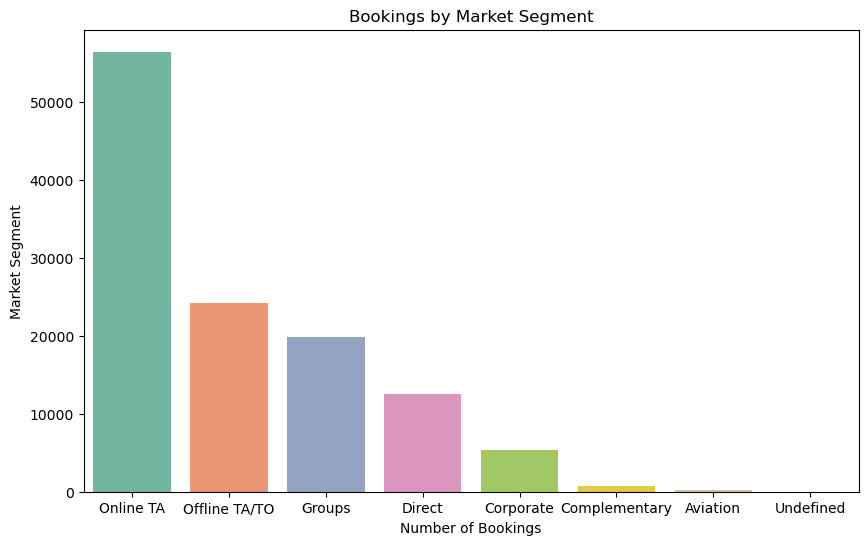

In [48]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='market_segment',
    data=df,
    order=df['market_segment'].value_counts().index,
    palette='Set2'
)

plt.title('Bookings by Market Segment')
plt.xlabel('Number of Bookings')
plt.ylabel('Market Segment')
plt.show()

##### Observation:

    The number of bookings varies across different market segments.

##### Insight:

    Some market segments contribute significantly more bookings than others.

##### Business Impact:

    Market segments with higher bookings are important sources of customers and revenue.

##### Conclusion:

    Understanding booking distribution across market segments helps hotels focus marketing efforts on the most valuable customer groups.

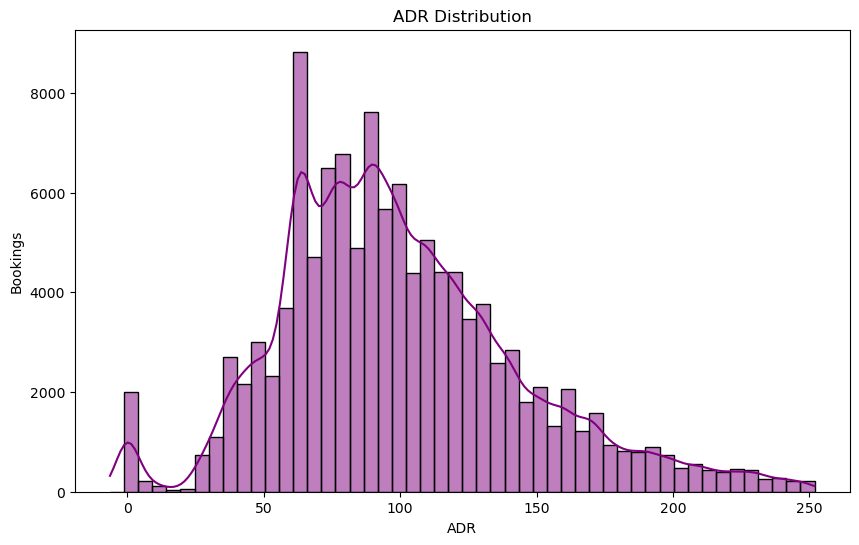

In [49]:
adr_filtered = df[df['adr'] < df['adr'].quantile(0.99)]

plt.figure(figsize=(10,6))

sns.histplot(
    adr_filtered['adr'],
    bins=50,
    kde=True,
    color='purple'
)

plt.title('ADR Distribution')
plt.xlabel('ADR')
plt.ylabel('Bookings')

plt.show()

##### Observation:

    Most bookings have ADR within a moderate range, while very high ADR values are rare.

##### Insight:

    Most customers prefer rooms with standard pricing rather than expensive rooms.

##### Business Impact:

    Regular-priced rooms contribute the majority of bookings and revenue.

##### Conclusion:

    The hotel follows a stable pricing strategy, and most customers book rooms within an affordable price range.

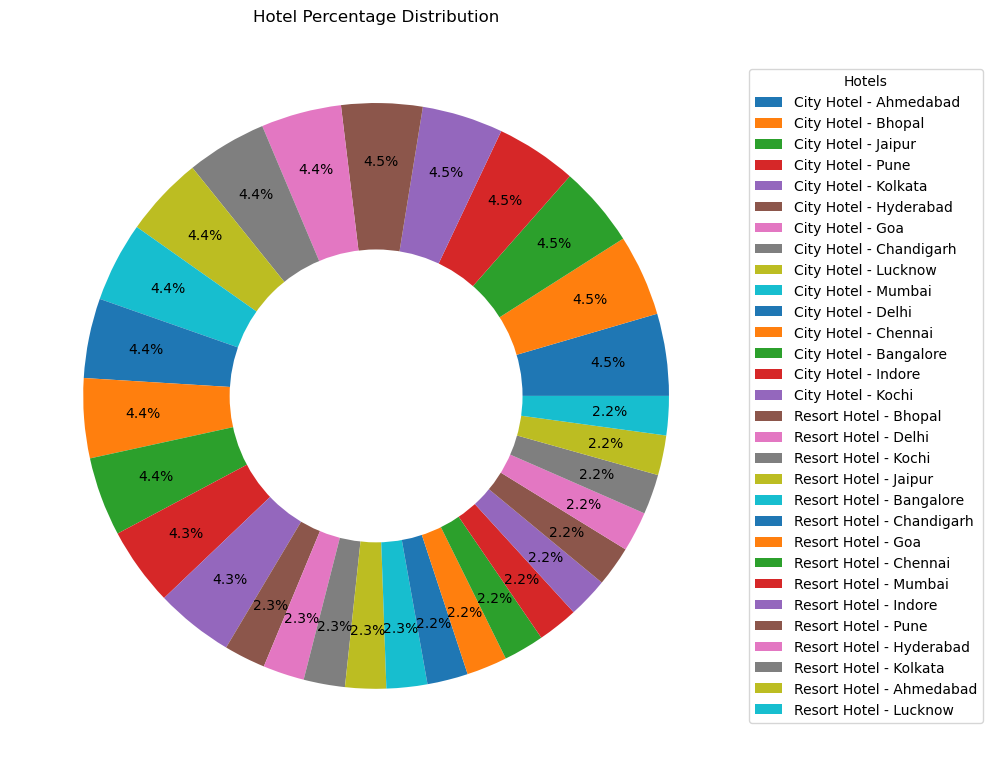

In [50]:
counts = df['hotel'].value_counts()

plt.figure(figsize=(10,10))
wedges, texts, autotexts = plt.pie(
    counts,
    labels=None,
    autopct='%1.1f%%',
    pctdistance=0.8
)

plt.legend(
    wedges,
    counts.index,
    title="Hotels",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

# Create donut hole
centre_circle = plt.Circle((0,0), 0.5, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Hotel Percentage Distribution")
plt.tight_layout()
plt.show()

##### Observation
    City Hotel accounts for a larger share of total bookings
    compared to Resort Hotel.

##### Insight
    Travelers prefer City Hotels, likely due to business travel,
    urban tourism, and better accessibility.

##### Business Impact
    City Hotels drive more bookings and revenue,
    making them the primary contributor to overall business performance.

##### Conclusion
    Hotel type distribution shows a clear preference for City Hotels.
    Management should focus resources and marketing strategies
    on City Hotels while finding ways to boost Resort Hotel demand
    during peak seasons.

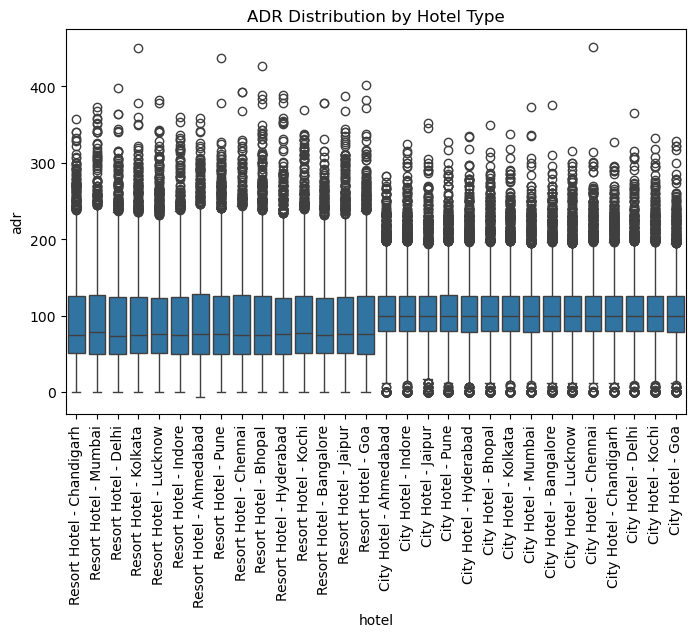

In [51]:
adr_filtered = df[df['adr'] < 500]

plt.figure(figsize=(8,5))

sns.boxplot(
    data=adr_filtered,
    x='hotel',
    y='adr'
)
plt.xticks(rotation=90)
plt.title('ADR Distribution by Hotel Type')
plt.show()

##### Observation:

    City Hotel has a slightly higher median ADR than Resort Hotel.
    A few extreme ADR values (outliers) are present.

##### Insight:

    Some bookings generate significantly higher revenue than average.
    Room prices vary across hotel types.

##### Business Impact:

    Hotels can identify premium pricing opportunities and optimize room rates.

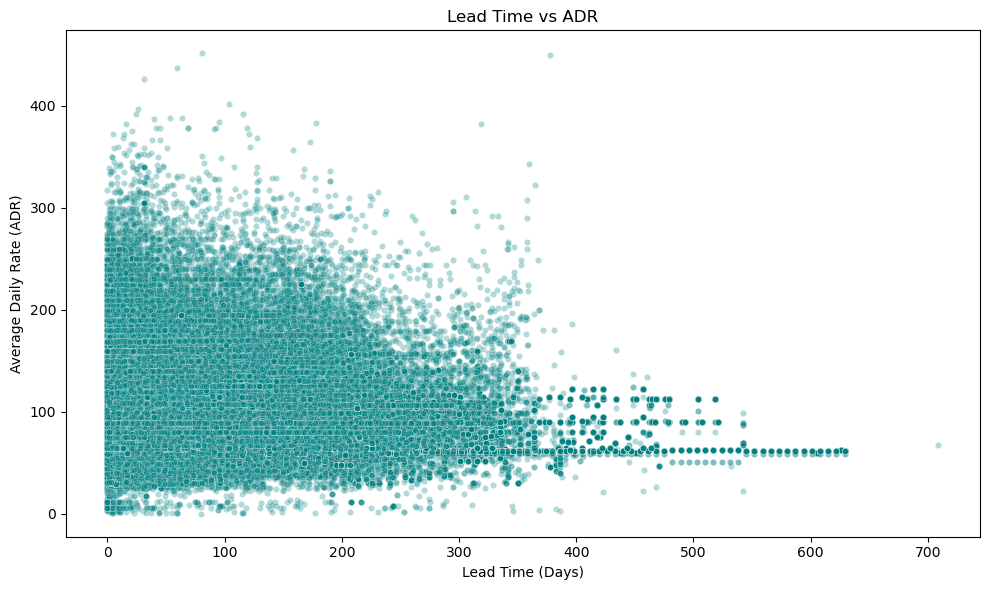

In [52]:
# Scatter Plot - Lead Time vs ADR (filtered)
adr_filtered = df[(df['adr'] < 500) & (df['adr'] > 0)]

plt.figure(figsize=(10,6))
sns.scatterplot(
    x='lead_time',
    y='adr',
    data=adr_filtered,
    alpha=0.3,
    color='teal',
    s=20          # smaller dot size
)
plt.title('Lead Time vs ADR')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Average Daily Rate (ADR)')
plt.tight_layout()
plt.show()

##### Observation:
    Bookings with very high lead times tend to have varying ADR values.

##### Insight:
    Customers who book early don't always get cheaper rates.

##### Business Impact:
    Hotels can use lead time data to apply dynamic pricing strategies.

##### Conclusion:
    Lead time and ADR do not show a strong linear relationship,
    meaning room pricing is influenced by multiple factors beyond just
    how early a customer books. Hotels should combine lead time data
    with seasonality and customer type to build smarter pricing models.

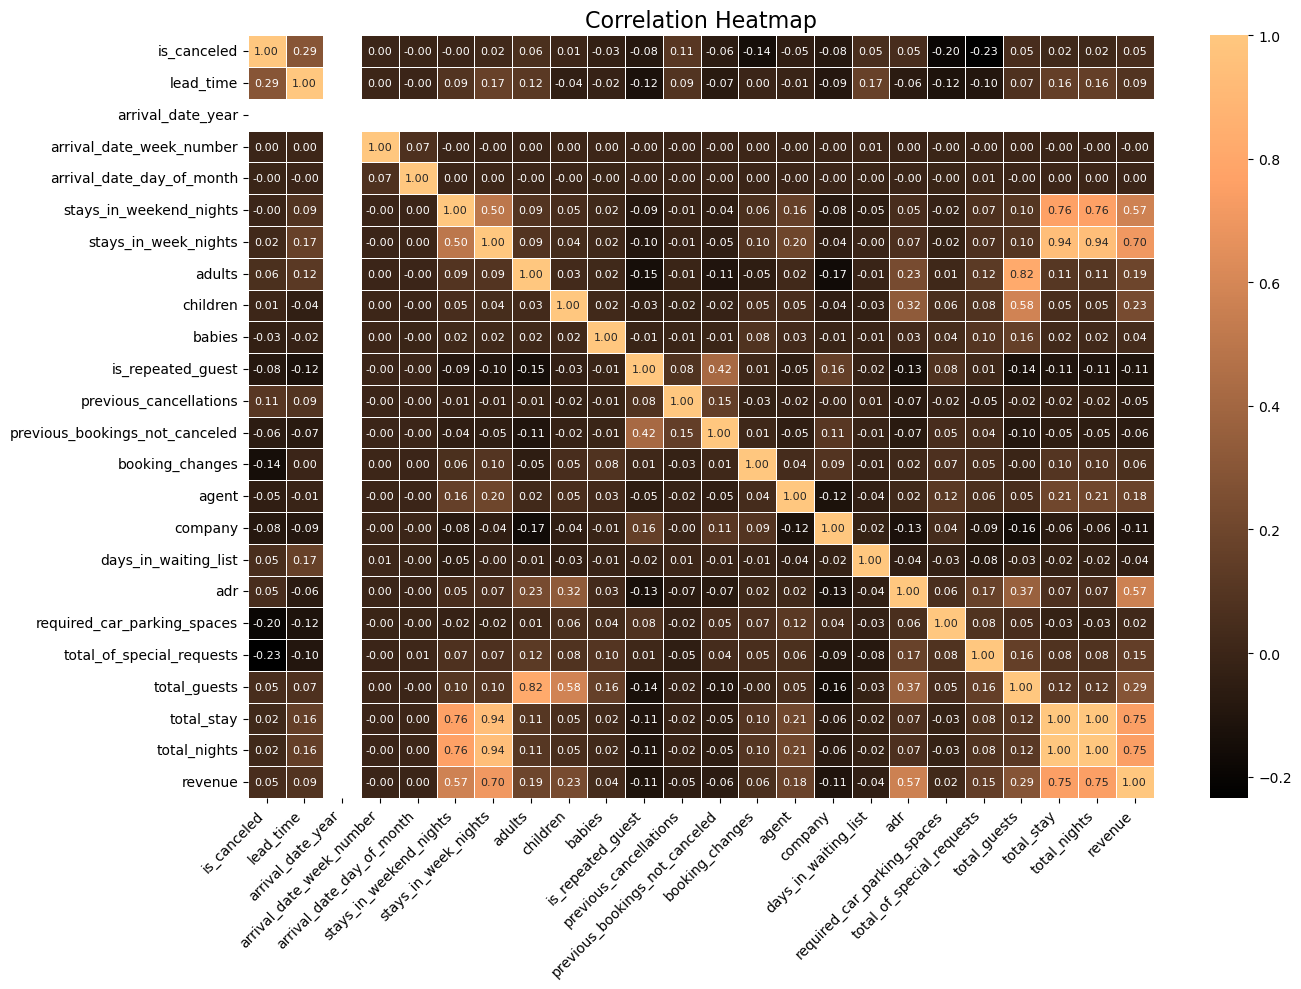

In [53]:
#Heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="copper",
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

##### Observation
    The heatmap shows positive and negative correlations
    between numerical variables in the dataset.

##### Insight
    Total nights, ADR, and lead time show notable correlations
    with revenue and cancellation rate.

##### Business Impact
    Understanding which variables are strongly correlated helps
    hotels focus on the right factors to improve revenue
    and reduce cancellations.

##### Conclusion
    The correlation heatmap reveals key relationships between
    booking features. Variables like ADR and total nights
    directly influence revenue, while lead time affects
    cancellation probability. These insights guide better
    pricing and booking management strategies.

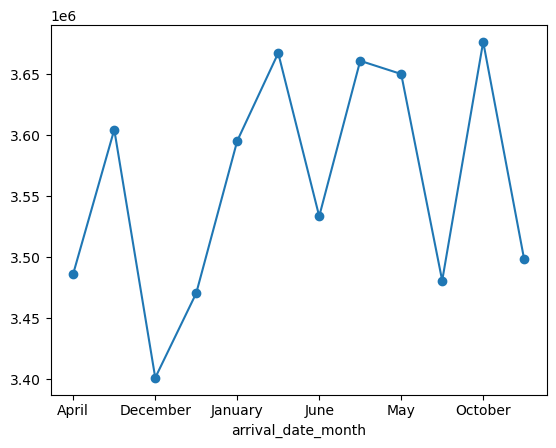

In [54]:
#Line Chart
monthly_revenue = df.groupby(
    'arrival_date_month'
)['revenue'].sum()

monthly_revenue.plot(
    kind='line',
    marker='o'
)

plt.show()

##### Observation
    Revenue fluctuates across different months,
    with certain months showing significantly higher revenue
    than others.

##### Insight
    Peak revenue months indicate high travel seasons,
    while low revenue months represent off-peak periods
    with fewer bookings.

##### Business Impact
    Identifying high and low revenue months helps hotels
    plan staffing, pricing, and promotional strategies
    more effectively throughout the year.

##### Conclusion
    Monthly revenue trends show clear seasonality in hotel bookings.
    Hotels should capitalize on peak months with premium pricing
    and attract more customers during off-peak months
    through targeted discounts and promotional offers.

#### 7. Correlation Analysis

In [55]:
corr = df.corr(
    numeric_only=True
)

corr

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_stay,total_nights,revenue
is_canceled,1.000000,0.293123,NaN,0.000500,-0.003858,-0.001791,0.024765,0.060017,0.005036,-0.032491,...,-0.046529,-0.082995,0.054186,0.047557,-0.195498,-0.234658,0.046522,0.017779,0.017779,0.046562
lead_time,0.293123,1.000000,NaN,0.004204,-0.000228,0.085671,0.165799,0.119519,-0.037613,-0.020915,...,-0.012640,-0.086250,0.170084,-0.063077,-0.116451,-0.095712,0.072265,0.157167,0.157167,0.086778
arrival_date_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,0.000500,0.004204,NaN,1.000000,0.071735,-0.003025,-0.002134,0.001395,0.003525,0.003893,...,-0.001734,-0.002781,0.007363,0.000892,-0.004556,-0.001465,0.003589,-0.002774,-0.002774,-0.001880
arrival_date_day_of_month,-0.003858,-0.000228,NaN,0.071735,1.000000,0.001203,0.001929,-0.000779,-0.000220,-0.003354,...,-0.000939,-0.002446,-0.004750,-0.001399,-0.004174,0.007877,-0.001198,0.001909,0.001909,0.000656
stays_in_weekend_nights,-0.001791,0.085671,NaN,-0.003025,0.001203,1.000000,0.498969,0.091871,0.045794,0.018483,...,0.161427,-0.079977,-0.054151,0.049342,-0.018554,0.072671,0.101426,0.762790,0.762790,0.572201
stays_in_week_nights,0.024765,0.165799,NaN,-0.002134,0.001929,0.498969,1.000000,0.092976,0.044203,0.020191,...,0.195135,-0.043641,-0.002020,0.065237,-0.024859,0.068192,0.101665,0.941005,0.941005,0.703020
adults,0.060017,0.119519,NaN,0.001395,-0.000779,0.091871,0.092976,1.000000,0.030440,0.018146,...,0.024994,-0.166778,-0.008283,0.230641,0.014785,0.122884,0.821105,0.105249,0.105249,0.193601
children,0.005036,-0.037613,NaN,0.003525,-0.000220,0.045794,0.044203,0.030440,1.000000,0.024030,...,0.050581,-0.042622,-0.033271,0.324853,0.056255,0.081736,0.579364,0.050865,0.050865,0.232074
babies,-0.032491,-0.020915,NaN,0.003893,-0.003354,0.018483,0.020191,0.018146,0.024030,1.000000,...,0.030266,-0.009459,-0.010621,0.029186,0.037383,0.097889,0.162688,0.022283,0.022283,0.037839


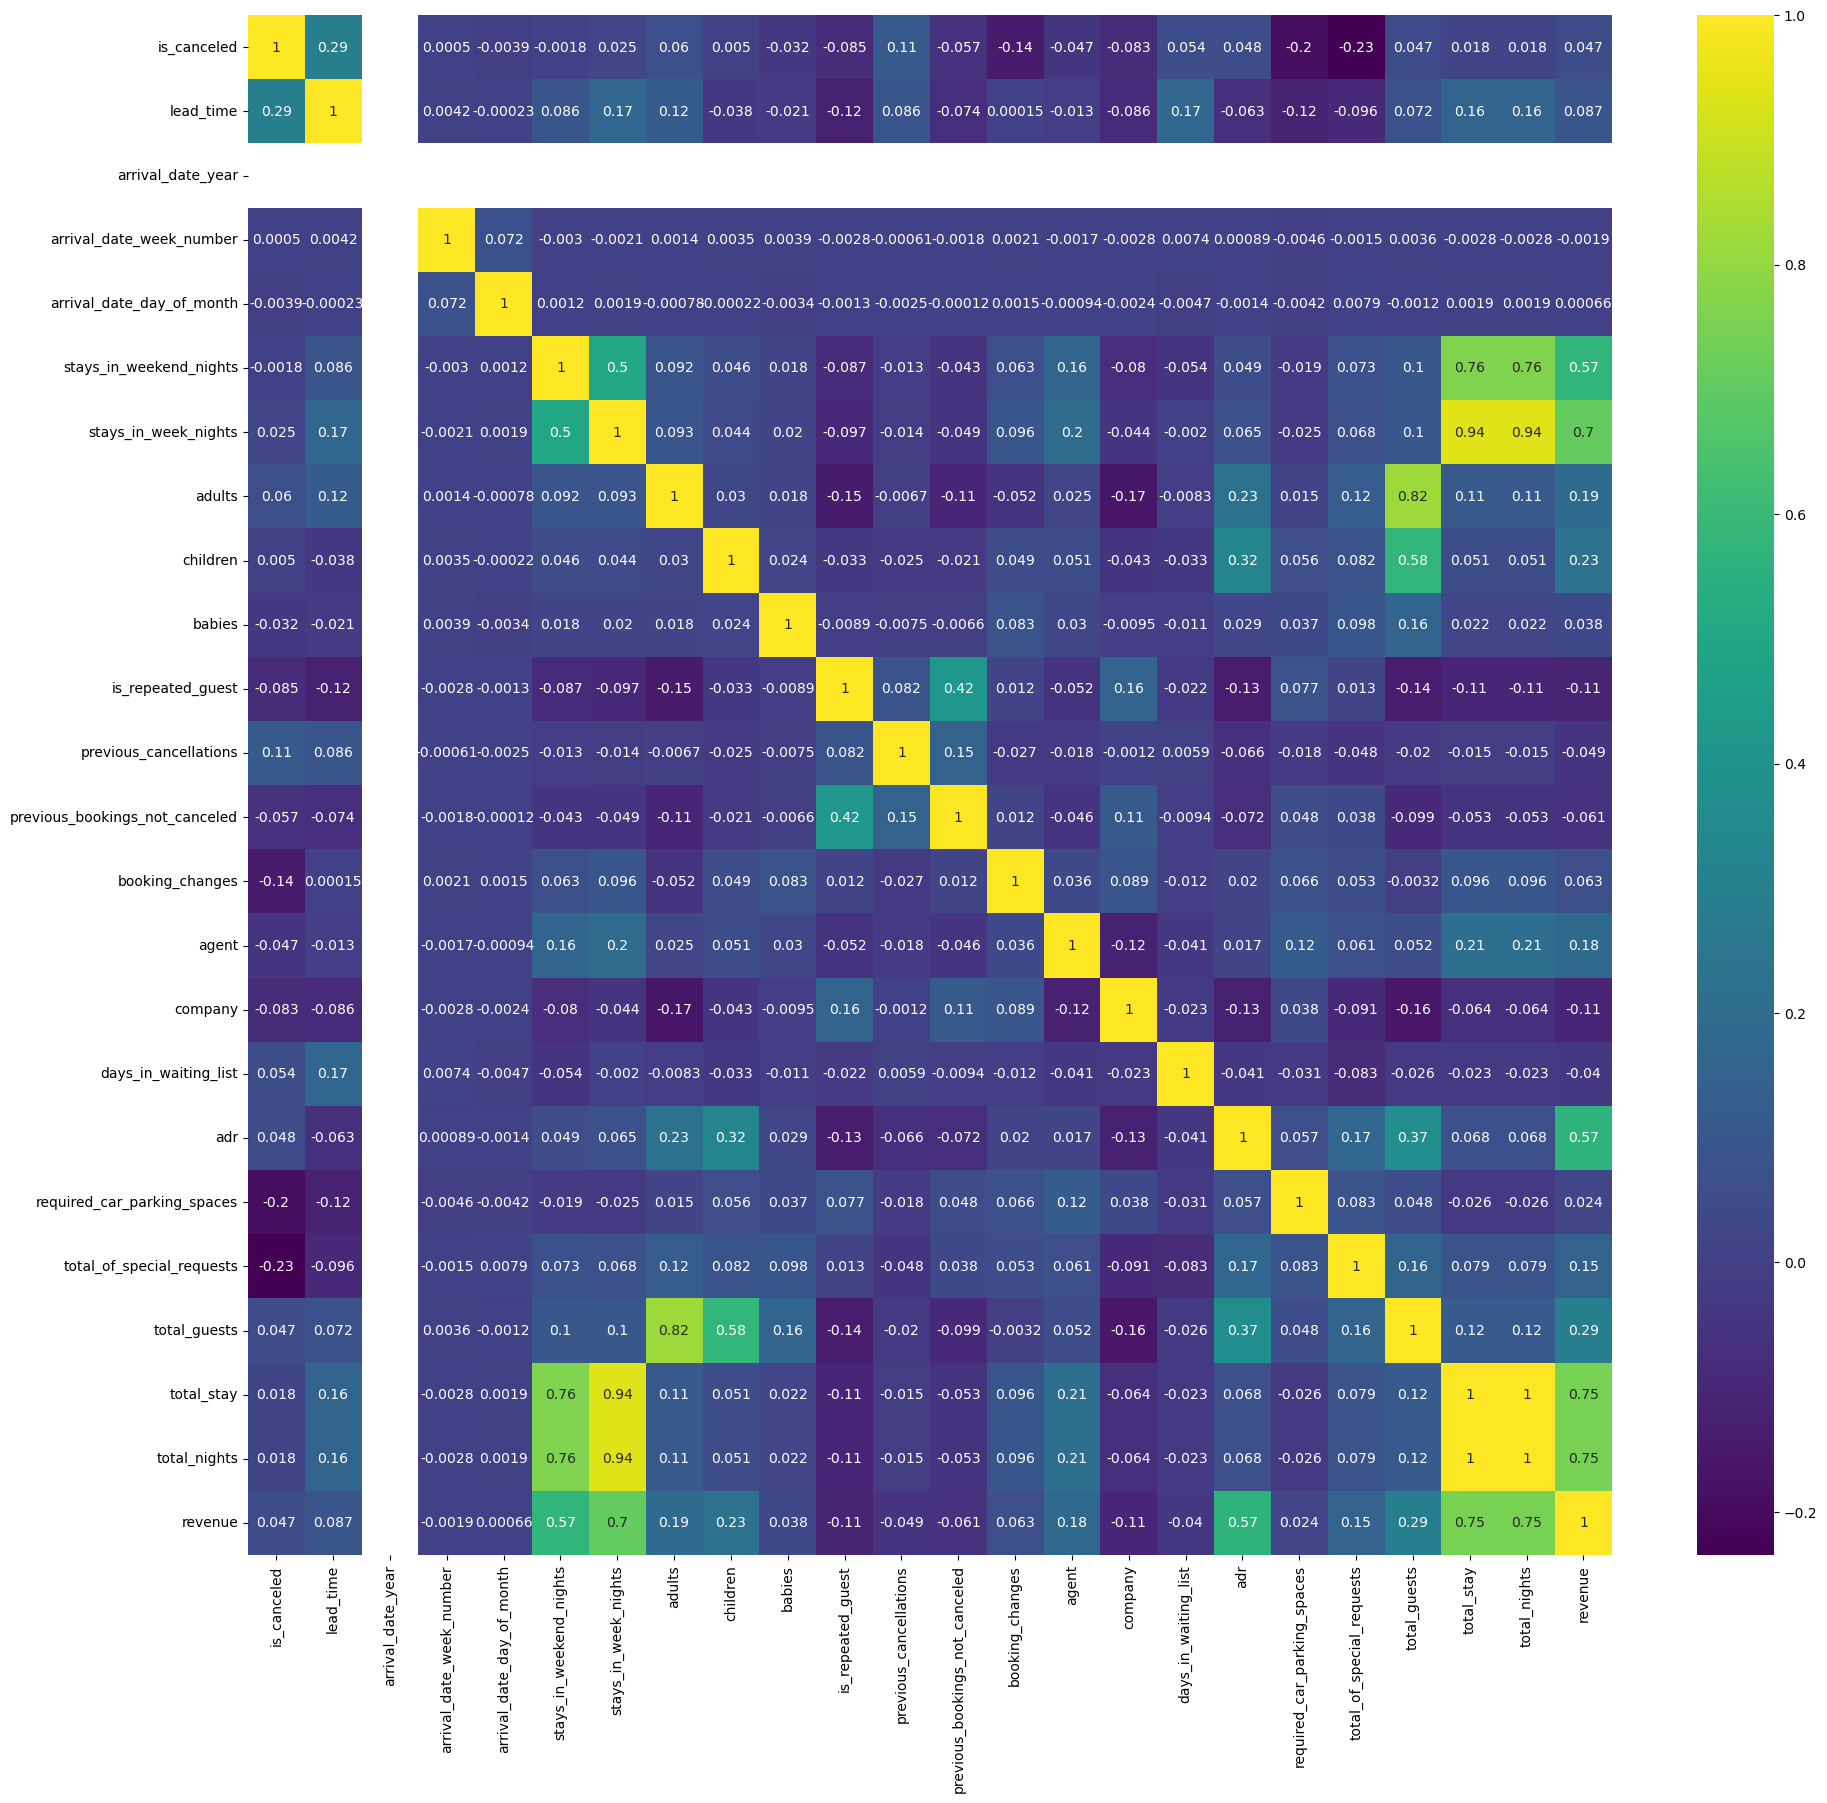

In [70]:
#Correlation Heatmap
plt.figure(figsize=(22,20))

sns.heatmap(
    corr,
    annot=True,
    cmap='viridis'
)

plt.show()

##### Observation
    Some variables show positive and negative correlations...
##### Insight
    Lead time, ADR, total stay...
##### Business Impact
    Management can focus on factors...
##### Conclusion
    Correlation analysis helps identify key drivers...

##### Factors affecting KPIs

In [57]:
#For Revenue
corr['revenue'].sort_values(
    ascending=False
)

revenue                           1.000000
total_nights                      0.748002
total_stay                        0.748002
stays_in_week_nights              0.703020
stays_in_weekend_nights           0.572201
adr                               0.565766
total_guests                      0.288384
children                          0.232074
adults                            0.193601
agent                             0.180234
total_of_special_requests         0.152998
lead_time                         0.086778
booking_changes                   0.062525
is_canceled                       0.046562
babies                            0.037839
required_car_parking_spaces       0.024082
arrival_date_day_of_month         0.000656
arrival_date_week_number         -0.001880
days_in_waiting_list             -0.040107
previous_cancellations           -0.048516
previous_bookings_not_canceled   -0.060723
company                          -0.105026
is_repeated_guest                -0.110447
arrival_dat

In [58]:
#For Cancellation
corr['is_canceled'].sort_values(
    ascending=False
)

is_canceled                       1.000000
lead_time                         0.293123
previous_cancellations            0.110133
adults                            0.060017
days_in_waiting_list              0.054186
adr                               0.047557
revenue                           0.046562
total_guests                      0.046522
stays_in_week_nights              0.024765
total_stay                        0.017779
total_nights                      0.017779
children                          0.005036
arrival_date_week_number          0.000500
stays_in_weekend_nights          -0.001791
arrival_date_day_of_month        -0.003858
babies                           -0.032491
agent                            -0.046529
previous_bookings_not_canceled   -0.057358
company                          -0.082995
is_repeated_guest                -0.084793
booking_changes                  -0.144381
required_car_parking_spaces      -0.195498
total_of_special_requests        -0.234658
arrival_dat

##### Observation

    Some variables show positive and negative correlations with revenue and cancellations.

##### Insight

    Lead time, ADR, total stay, and deposit type influence hotel performance.

##### Business Impact

    Management can focus on factors that have the greatest impact on revenue and occupancy.

##### Conclusion

    Correlation analysis helps identify key drivers of hotel business performance.

# Business Recommendations

1. Reduce cancellations through advance deposit policies.
2. Focus marketing on high-revenue customer segments.
3. Use dynamic pricing based on ADR trends.
4. Target countries generating the highest revenue.
5. Improve loyalty programs for repeat customers.
6. Increase promotions during low-demand periods.

# Conclusion

   1. This EDA project analyzed hotel booking data to understand customer behavior, booking trends, cancellations, and revenue patterns.

   2. The analysis revealed that City Hotels receive more bookings, transient customers contribute the highest revenue, and factors such as lead time, ADR, market segment, and deposit type significantly influence hotel performance.

   3. Using data cleaning, visualization, pivot tables, GroupBy analysis, and correlation analysis, valuable business insights were generated. These    insights can help hotel management improve occupancy, reduce cancellations, optimize pricing strategies, and maximize revenue.

   4. Overall, this project demonstrates how data-driven decision-making can support better hotel management and business growth.